# Phase 3 - Federated Learning
## Secure AI-Based Handwritten Text Recognition for Indian Scripts

### Abstract alignment:
- Privacy preservation - Training occurs on local devices/clients, raw handwriting images never sent anywhere
- FedAvg algorithm - Only encrypted model weight updates are exchanged with the central server
- 2 simulated clients - Hindi, Telugu (one per language/device, matching Phase 1+2 scope)

### Expected Outcome:
> Implementation of Federated Learning to ensure data privacy, where training occurs on local devices without transferring handwritten data to external servers.

### Builds on Phase 2:
- Loads model_best.pth as the starting global model
- Uses the same label_map.json and processed/ data from Phase 1

### Resumable: round-level checkpoints - survives Colab runtime disconnects
### RAM-safe: only one client model copy exists in memory at a time, released right after use

---
## Cell 1 - Install Dependencies

In [1]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# Correctly install torch and torchvision with the index URL
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torch', 'torchvision', '--index-url', 'https://download.pytorch.org/whl/cu118'])
install('matplotlib')
install('scikit-learn')
install('tqdm')
install('opencv-python-headless')
install('cryptography')
install('pandas')
install('psutil')

import torch
print('✅ Dependencies installed!')
print(f'   PyTorch  : {torch.__version__}')
print(f'   CUDA     : {torch.version.cuda}')
print(f'   cuDNN    : {torch.backends.cudnn.version()}')

✅ Dependencies installed!
   PyTorch  : 2.11.0+cu128
   CUDA     : 12.8
   cuDNN    : 91900


---
## Cell 2 - Imports

In [2]:
# ============================================
# CELL 2 - Imports
# ============================================
import os, gc, json, copy, pickle, random, time, hashlib, warnings, logging
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import psutil
from pathlib import Path
from tqdm import tqdm
from datetime import datetime
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader

from cryptography.fernet import Fernet

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)

# Deterministic + TF32
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.benchmark        = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device   : {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU      : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    print(f'   RAM      : {psutil.virtual_memory().total/1e9:.1f} GB')
else:
    print('   ⚠️ No GPU — go to Runtime > Change runtime type > T4 GPU')

Device   : cuda
   GPU      : Tesla T4
   VRAM     : 15.6 GB
   RAM      : 13.6 GB


---
## Cell 3 - Drive Mount + Paths (standard block - same across all phases)

In [3]:
# ============================================
# CELL 3 - Drive Mount + Paths
# ============================================
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR  = Path('/content/drive/MyDrive/OCR_Project')
DATA_DIR  = BASE_DIR / 'processed'
MODEL_DIR = BASE_DIR / 'models'
LOG_DIR   = BASE_DIR / 'logs'
OUT_DIR   = BASE_DIR / 'outputs'

TRAIN_DIR      = DATA_DIR  / 'train'
VAL_DIR        = DATA_DIR  / 'val'
TEST_DIR       = DATA_DIR  / 'test'
CHECKPOINT_DIR = MODEL_DIR / 'checkpoints'
FINAL_DIR      = MODEL_DIR / 'final'
FL_DIR         = MODEL_DIR / 'federated'

# All subdirs
for d in [
    FL_DIR,
    FL_DIR / 'client_checkpoints',
    FL_DIR / 'global_checkpoints',
    FL_DIR / 'round_logs',
    LOG_DIR,
    OUT_DIR / 'evaluation',
    OUT_DIR / 'evaluation' / 'figures',
    OUT_DIR / 'reports',
    OUT_DIR / 'exports',
    OUT_DIR / 'privacy',
    OUT_DIR / 'metrics',
]:
    d.mkdir(parents=True, exist_ok=True)

print('✅ Drive mounted + all directories created!')
print(f'   Base    : {BASE_DIR}')
print(f'   Data    : {DATA_DIR}')
print(f'   FL Dir  : {FL_DIR}')

Mounted at /content/drive
✅ Drive mounted + all directories created!
   Base    : /content/drive/MyDrive/OCR_Project
   Data    : /content/drive/MyDrive/OCR_Project/processed
   FL Dir  : /content/drive/MyDrive/OCR_Project/models/federated


In [4]:
# ============================================
# VERIFY LOCAL DATASET
# ============================================

!find /content/processed_local/train -type f | wc -l
!find /content/processed_local/val   -type f | wc -l
!find /content/processed_local/test  -type f | wc -l

find: ‘/content/processed_local/train’: No such file or directory
0
find: ‘/content/processed_local/val’: No such file or directory
0
find: ‘/content/processed_local/test’: No such file or directory
0


In [5]:
# ============================================
# EXTRACT ALL TAR FILES TO LOCAL SSD
# ============================================

!rm -rf /content/processed_local

!mkdir -p /content/processed_local/train
!mkdir -p /content/processed_local/val
!mkdir -p /content/processed_local/test

# -------------------------
# TRAIN
# -------------------------

!tar -xf /content/drive/MyDrive/OCR_Project/train_hindi.tar \
-C /content/processed_local/train

!tar -xf /content/drive/MyDrive/OCR_Project/train_telugu.tar \
-C /content/processed_local/train

# -------------------------
# VAL
# -------------------------

!tar -xf /content/drive/MyDrive/OCR_Project/val_hindi.tar \
-C /content/processed_local/val

!tar -xf /content/drive/MyDrive/OCR_Project/val_telugu.tar \
-C /content/processed_local/val

# -------------------------
# TEST
# -------------------------

!tar -xf /content/drive/MyDrive/OCR_Project/test_hindi.tar \
-C /content/processed_local/test

!tar -xf /content/drive/MyDrive/OCR_Project/test_telugu.tar \
-C /content/processed_local/test

print("All TAR files extracted successfully!")

All TAR files extracted successfully!


In [6]:
# ============================================
# CELL 4A - Local Data Extraction
# ============================================
import subprocess

LOCAL_DATA_DIR = Path('/content/processed_local')

def count_pngs(path):
    return sum(1 for _ in Path(path).rglob('*.png')) if Path(path).exists() else 0

EXPECTED = {'train': 709214, 'val': 151708, 'test': 151706}

def is_complete():
    return all(count_pngs(LOCAL_DATA_DIR/s) >= EXPECTED[s]
               for s in ['train', 'val', 'test'])

if is_complete():
    print('✅ Local data already complete — skipping extraction')
else:
    print('Extracting tar files to local SSD...')
    LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

    for split in ['train', 'val', 'test']:
        tar_path = BASE_DIR / f'{split}.tar'
        if tar_path.exists():
            print(f'  Extracting {split}...')
            start = time.time()
            subprocess.run(['tar', '-xf', str(tar_path),
                           '-C', str(LOCAL_DATA_DIR)], check=True)
            print(f'  ✅ {split}: {count_pngs(LOCAL_DATA_DIR/split):,} files '
                  f'({time.time()-start:.1f}s)')
        else:
            print(f'  ⚠️ {split}.tar not found at {tar_path}')

# Override to local
DATA_DIR  = LOCAL_DATA_DIR
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'val'
TEST_DIR  = DATA_DIR / 'test'

print(f'\nData source: {DATA_DIR}')
for split in ['train', 'val', 'test']:
    print(f'  {split:5}: {count_pngs(DATA_DIR/split):,} images')

✅ Local data already complete — skipping extraction

Data source: /content/processed_local
  train: 709,214 images
  val  : 151,708 images
  test : 151,706 images


---
## Cell 4 - Load Phase 2 Label Map + Model Architecture

In [7]:
# ============================================
# CELL 4B - Label Map + Model Architecture
# ============================================
MODEL_DIR_DRIVE = BASE_DIR / 'models'   # always load from Drive

with open(MODEL_DIR_DRIVE / 'label_map.json', 'r') as f:
    label_data = json.load(f)

label2idx   = label_data['label2idx']
idx2label   = {int(k): v for k, v in label_data['idx2label'].items()}
NUM_CLASSES = label_data['num_classes']
print(f'✅ Label map loaded! Classes: {NUM_CLASSES}')

# ── MUST match Phase 2 Cell 6 exactly ──────────────────
class CNN_BiLSTM_CTC(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.GELU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.GELU(), nn.MaxPool2d((2,1),(2,1)),
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.GELU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.GELU(), nn.MaxPool2d((2,1),(2,1)),
            nn.Dropout2d(0.30)
        )
        self.bilstm = nn.LSTM(512*4, 256, num_layers=2, bidirectional=True,
                              batch_first=True, dropout=0.30)
        self.layer_norm = nn.LayerNorm(512)
        self.fc = nn.Linear(512, num_classes + 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        f = self.cnn(x)
        B, C, H, W = f.size()
        f = f.permute(0,3,1,2).reshape(B, W, C*H)
        f, _ = self.bilstm(f)
        f = self.layer_norm(f)
        return self.fc(f).permute(1, 0, 2)

global_model = CNN_BiLSTM_CTC(NUM_CLASSES).to(DEVICE)

# Load Phase 2 best model
best_model_path = MODEL_DIR_DRIVE / 'final' / 'model_best.pth'
if best_model_path.exists():
    ckpt = torch.load(
    best_model_path,
    map_location=DEVICE,
    weights_only=False
)
    global_model.load_state_dict(ckpt['model_state'], strict=True)
    print(f'✅ Phase 2 model loaded!')
    print(f'   val_acc  : {ckpt["val_acc"]:.4f}')
    print(f'   best_acc : {ckpt.get("best_acc", 0.0):.4f}')

    # Checkpoint hash for integrity
    model_bytes = open(best_model_path, 'rb').read()
    print(f'   SHA256   : {hashlib.sha256(model_bytes).hexdigest()[:16]}...')
    del ckpt
else:
    raise FileNotFoundError('model_best.pth not found! Run Phase 2 first.')

total_p = sum(p.numel() for p in global_model.parameters())
print(f'\nModel Info:')
print(f'   Total Params : {total_p:,}')
print(f'   Model Size   : {total_p * 4 / 1e6:.1f} MB (fp32)')
print(f'   Device       : {DEVICE}')

✅ Label map loaded! Classes: 427
✅ Phase 2 model loaded!
   val_acc  : 0.9594
   best_acc : 0.9594
   SHA256   : d3a1331bc8266e7a...

Model Info:
   Total Params : 11,023,404
   Model Size   : 44.1 MB (fp32)
   Device       : cuda


---
## Cell 5 - Client Datasets (Hindi + Telugu = 2 simulated devices, RAM-safe)

Same lazy-loading pattern as Phase 2: only (path, label) pairs are stored per
client, images are decoded one at a time inside `__getitem__` and discarded
right after use.

In [8]:
# ============================================
# CELL 5 - Client Datasets (Hindi + Telugu)
# ============================================
IMG_H, IMG_W   = 64, 128
BATCH_SIZE      = 64
NUM_WORKERS     = 0        # segfault fix
USE_PIN_MEMORY  = torch.cuda.is_available()

class ClientDataset(Dataset):
    def __init__(self, data_dir, label2idx, split, language):
        self.samples   = []
        self.label2idx = label2idx
        split_dir = Path(data_dir) / split
        exts = {'.png', '.jpg', '.jpeg'}

        lang_dir = split_dir / language
        if lang_dir.exists():
            for label_folder in sorted(lang_dir.iterdir()):
                if not label_folder.is_dir(): continue
                label = label_folder.name
                if label not in label2idx: continue
                for img_path in label_folder.iterdir():
                    if img_path.suffix.lower() in exts:
                        self.samples.append((str(img_path), label2idx[label]))
        random.shuffle(self.samples)
        print(f'   {language:10}: {len(self.samples):,} samples | '
              f'{len(set(s[1] for s in self.samples))} classes')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((IMG_H, IMG_W), dtype=np.uint8)
        img = cv2.resize(img, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)
        return torch.from_numpy(img.astype(np.float32)/255.0).unsqueeze(0), label

    def get_language(self, idx):
        return self.samples[idx][0].split('/')[-3]

# Client config
CLIENTS = {'Hindi': 'Hindi', 'Telugu': 'Telugu'}

print('Client Datasets:')
client_datasets = {
    name: ClientDataset(DATA_DIR, label2idx, 'train', lang)
    for name, lang in CLIENTS.items()
}

client_loaders = {
    name: DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True,
                     num_workers=0, pin_memory=USE_PIN_MEMORY)
    for name, ds in client_datasets.items()
}

total = sum(len(ds) for ds in client_datasets.values())
print(f'\nTotal client samples : {total:,}')
for name, ds in client_datasets.items():
    pct = len(ds)/total*100
    print(f'  {name:10}: {len(ds):,} ({pct:.1f}%)')

Client Datasets:
   Hindi     : 193,414 samples | 46 classes
   Telugu    : 515,800 samples | 381 classes

Total client samples : 709,214
  Hindi     : 193,414 (27.3%)
  Telugu    : 515,800 (72.7%)


---
## Cell 6 - Encrypted Weight Updates (Privacy Layer)

In [9]:
# ============================================
# CELL 6 - Encrypted Weight Updates
# ============================================
import time as _time

key_path = FL_DIR / 'encryption_key.key'

if key_path.exists():
    with open(key_path, 'rb') as f:
        ENCRYPT_KEY = f.read()
    print('✅ Existing encryption key loaded')
else:
    ENCRYPT_KEY = Fernet.generate_key()
    with open(key_path, 'wb') as f:
        f.write(ENCRYPT_KEY)
    print('✅ New encryption key generated and saved')

fernet = Fernet(ENCRYPT_KEY)

def encrypt_weights(model_state_dict):
    serialized = pickle.dumps({k: v.cpu().numpy() for k, v in model_state_dict.items()})
    encrypted  = fernet.encrypt(serialized)
    del serialized
    return encrypted

def decrypt_weights(encrypted_data):
    serialized = fernet.decrypt(encrypted_data)
    weights    = pickle.loads(serialized)
    del serialized
    return {k: torch.tensor(v).to(DEVICE) for k, v in weights.items()} # Fix: Move decrypted tensors to DEVICE

# Verify + stats
t0 = _time.time()
test_state = global_model.state_dict()
encrypted  = encrypt_weights(test_state)
decrypted  = decrypt_weights(encrypted)
enc_time   = _time.time() - t0

raw_size = sum(v.numel()*4 for v in test_state.values()) / 1e6
enc_size = len(encrypted) / 1e6

assert all(torch.allclose(test_state[k], decrypted[k]) for k in test_state)

print(f'\nEncryption Stats:')
print(f'   Algorithm        : Fernet (AES-128-CBC + HMAC-SHA256)')
print(f'   Key size         : {len(ENCRYPT_KEY)*8} bits')
print(f'   Raw weights size : {raw_size:.2f} MB')
print(f'   Encrypted size   : {enc_size:.2f} MB')
print(f'   Overhead         : {(enc_size-raw_size)/raw_size*100:.1f}%')
print(f'   Enc+Dec time     : {enc_time*1000:.1f} ms')
print(f'   SHA256 key hash  : {hashlib.sha256(ENCRYPT_KEY).hexdigest()[:16]}...')
print('✅ Encryption verified!')
del test_state, encrypted, decrypted

✅ Existing encryption key loaded

Encryption Stats:
   Algorithm        : Fernet (AES-128-CBC + HMAC-SHA256)
   Key size         : 352 bits
   Raw weights size : 44.11 MB
   Encrypted size   : 58.81 MB
   Overhead         : 33.3%
   Enc+Dec time     : 2071.8 ms
   SHA256 key hash  : 7eeea8b2ff7eb1ae...
✅ Encryption verified!


---
## Cell 7 - FedAvg Algorithm (RAM-safe)

**RAM safety notes:**
- `local_train` deep-copies the global model once per client per round (unavoidable -
  each client needs its own independent copy to train on). That single copy is
  explicitly `del`eted as soon as its encrypted weights have been extracted, so at
  most one extra full model copy exists in memory at any moment - never one per client
  simultaneously.
- `fed_avg` builds the averaged state dict directly on `DEVICE` and decrypts one
  client's weights at a time inside the loop (not all clients' weights at once),
  then immediately discards each decrypted client state dict after it's been folded
  into the running average.

In [10]:
# ============================================
# CELL 7 - Local Training + FedAvg (AMP + tqdm)
# ============================================

import time
from tqdm.auto import tqdm

scaler = torch.cuda.amp.GradScaler(
    enabled=torch.cuda.is_available()
)
def local_train(model, loader, client_name, epochs=2, lr=1e-4):
    """
    Runs ON the client device.

    Raw images NEVER leave this client.

    Returns:
        encrypted_weights,
        avg_loss,
        n_samples,
        training_time,
        images_per_second
    """

    local_model = copy.deepcopy(model).to(DEVICE)

    optimizer = optim.Adam(
        local_model.parameters(),
        lr=lr
    )

    # -----------------------------
    # NEW: Scheduler
    # -----------------------------

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(epochs, 1)
    )

    criterion = nn.CTCLoss(
        blank=NUM_CLASSES,
        reduction="mean",
        zero_infinity=True
    )

    local_model.train()

    total_loss = 0.0
    batches = 0

    start_time = time.time()

    # -----------------------------
    # GPU Memory Reset
    # -----------------------------

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    # ===================================================
    # TRAIN
    # ===================================================

    for epoch in range(epochs):

        epoch_bar = tqdm(
            loader,
            desc=f"Local Epoch {epoch+1}/{epochs}",
            leave=False,
            dynamic_ncols=True,
            colour="green"
        )

        for imgs, labels in epoch_bar:

            try:

                imgs = imgs.to(
                    DEVICE,
                    non_blocking=True
                )

                labels = labels.to(
                    DEVICE,
                    non_blocking=True
                )

                optimizer.zero_grad(set_to_none=True)

                # -----------------------------
                # NEW: Mixed Precision
                # -----------------------------

                with torch.amp.autocast(
                    "cuda",
                    enabled=torch.cuda.is_available()
                ):

                    output = local_model(imgs)

                    T, B, C = output.size()

                    input_lengths = torch.full(
                        (B,),
                        T,
                        dtype=torch.long,
                        device=DEVICE
                    )

                    target_lengths = torch.ones(
                        B,
                        dtype=torch.long,
                        device=DEVICE
                    )

                    log_probs = output.log_softmax(2)

                    loss = criterion(
                        log_probs,
                        labels,
                        input_lengths,
                        target_lengths
                    )

                # -----------------------------
                # NEW: GradScaler
                # -----------------------------

                scaler.scale(loss).backward()

                scaler.unscale_(optimizer)

                nn.utils.clip_grad_norm_(
                    local_model.parameters(),
                    5.0
                )

                scaler.step(optimizer)

                scaler.update()

                total_loss += loss.item()

                batches += 1

                epoch_bar.set_postfix(

                    Loss=f"{loss.item():.4f}",

                    LR=f"{optimizer.param_groups[0]['lr']:.2e}"

                )

                del (
                    imgs,
                    labels,
                    output,
                    log_probs,
                    loss,
                    input_lengths,
                    target_lengths
                )

            except RuntimeError as e:

                if "out of memory" in str(e):

                    print("\n⚠ CUDA OOM detected... clearing cache.")

                    torch.cuda.empty_cache()

                    gc.collect()

                    raise RuntimeError(
                        "Local Training OOM."
                    )

                else:
                    raise

        scheduler.step()

    # ===================================================
    # TRAINING SUMMARY
    # ===================================================

    training_time = time.time() - start_time

    avg_loss = total_loss / max(batches, 1)

    images_per_second = (

        len(loader.dataset) * epochs

    ) / max(training_time, 1e-6)

    gpu_memory = 0
    peak_gpu = 0

    if torch.cuda.is_available():

        gpu_memory = (
            torch.cuda.memory_allocated()
            / 1024**2
        )

        peak_gpu = (
            torch.cuda.max_memory_allocated()
            / 1024**2
        )

    encrypted_weights = encrypt_weights(
        local_model.state_dict()
    )

    n_samples = len(loader.dataset)

    print()

    print("-"*60)

    print("Client Training Summary")

    print("-"*60)

    print(f"Samples             : {n_samples:,}")

    print(f"Average Loss        : {avg_loss:.6f}")

    print(f"Training Time       : {training_time:.2f} sec")

    print(f"Images / Second     : {images_per_second:.2f}")

    print(f"Final Learning Rate : {optimizer.param_groups[0]['lr']:.2e}")

    if torch.cuda.is_available():

        print(f"GPU Memory          : {gpu_memory:.2f} MB")

        print(f"Peak GPU Memory     : {peak_gpu:.2f} MB")

    print("-"*60)

    del local_model
    del optimizer
    del scheduler

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return encrypted_weights, avg_loss, n_samples, training_time, images_per_second

def fed_avg(global_model, encrypted_updates, client_sizes):
    total = sum(client_sizes)
    avg_state = {}
    for i, enc_w in enumerate(encrypted_updates):
        w = decrypt_weights(enc_w)
        weight = client_sizes[i] / total
        for k, v in w.items():
            v_dev = v.to(DEVICE)
            avg_state[k] = avg_state.get(k, torch.zeros_like(v_dev)) + v_dev * weight
        del w
    global_model.load_state_dict(avg_state)
    del avg_state
    return global_model

print('✅ local_train + fed_avg defined (AMP + AdamW + tqdm + img/sec)')

✅ local_train + fed_avg defined (AMP + AdamW + tqdm + img/sec)


---
## Cell 8 - Global Validation Function

In [11]:
# ============================================
# CELL 8 - Global Validation
# Production Ready
# tqdm + AMP + Statistics + Confidence
# ============================================
#
# FIX APPLIED:
#
# Original:
# pred = out.argmax(2)[0]
#
# This always reads timestep-0 from a CTC sequence.
# A CTC model predicts across multiple timesteps,
# therefore the best prediction can appear anywhere.
#
# Correct solution:
#
# • Ignore blank class
# • Search across ALL timesteps
# • Select highest confidence prediction
#
# This gives correct evaluation for
# CNN + BiLSTM + CTC.
# ============================================

import time
import gc
import json

from tqdm.auto import tqdm
from torch.amp import autocast

# ----------------------------------------------------------
# CTC Decoder
# ----------------------------------------------------------

def decode_ctc_single_char(output, num_classes):
    """
    Parameters
    ----------
    output : Tensor
        Shape = (T, B, C+1)

    Returns
    -------
    pred_classes : Tensor
        Predicted class indices

    confidences : Tensor
        Confidence score of each prediction
    """

    probs = output.log_softmax(2).exp()

    T, B, C = probs.size()

    probs_no_blank = probs.clone()

    probs_no_blank[:, :, num_classes] = 0.0

    flat = (
        probs_no_blank
        .permute(1, 0, 2)
        .reshape(B, -1)
    )

    best_flat_idx = flat.argmax(dim=1)

    confidences = flat.gather(
        1,
        best_flat_idx.unsqueeze(1)
    ).squeeze(1)

    pred_classes = best_flat_idx % C

    return pred_classes, confidences


# ----------------------------------------------------------
# Global Validation
# ----------------------------------------------------------

def validate_global(
    model,
    data_dir,
    label2idx,
    languages=("Hindi", "Telugu")
):

    model.eval()

    overall_correct = 0
    overall_total = 0

    per_lang_acc = {}

    # --------------------------------------
    # NEW
    # Validation Statistics
    # --------------------------------------

    validation_stats = {}

    validation_metadata = {

        "timestamp": time.strftime(
            "%Y-%m-%d %H:%M:%S"
        ),

        "device": str(DEVICE),

        "batch_size": 128,

        "architecture": "CNN + BiLSTM + CTC",

        "languages": list(languages)

    }

    overall_confidence = 0.0

    overall_predictions = 0

    t_start = time.time()

    # --------------------------------------
    # GPU Monitoring
    # --------------------------------------

    if torch.cuda.is_available():

        torch.cuda.reset_peak_memory_stats()

    # --------------------------------------
    # Validation
    # --------------------------------------

    with torch.no_grad():

        for lang in languages:

            ds = ClientDataset(

                data_dir,

                label2idx,

                "val",

                lang

            )

            loader = DataLoader(

                ds,

                batch_size=128,

                shuffle=False,

                num_workers=0,

                pin_memory=USE_PIN_MEMORY

            )

            correct = 0

            total = 0

            language_confidence = 0.0

            val_bar = tqdm(

                loader,

                desc=f"Validating {lang}",

                leave=False,

                dynamic_ncols=True,

                colour="cyan"

            )
            # --------------------------------------------------
            # Validation Loop
            # --------------------------------------------------

            for batch_idx, (imgs, labels) in enumerate(val_bar):

                try:

                    imgs = imgs.to(
                        DEVICE,
                        non_blocking=True
                    )

                    with autocast(
                        "cuda",
                        enabled=torch.cuda.is_available()
                    ):

                        out = model(imgs)

                    # ------------------------------------------
                    # Correct CTC Decoding
                    # ------------------------------------------

                    pred, confidences = decode_ctc_single_char(
                        out,
                        NUM_CLASSES
                    )

                    batch_correct = (
                        pred.cpu() == labels
                    ).sum().item()

                    correct += batch_correct

                    total += labels.size(0)

                    # ------------------------------------------
                    # Confidence Tracking
                    # ------------------------------------------

                    batch_conf = confidences.sum().item()

                    language_confidence += batch_conf

                    overall_confidence += batch_conf

                    overall_predictions += len(labels)

                    # ------------------------------------------
                    # Live Progress
                    # ------------------------------------------

                    val_bar.set_postfix(

                        Acc=f"{100*correct/max(total,1):.2f}%",

                        Conf=f"{100*language_confidence/max(total,1):.2f}%"

                    )

                    # ------------------------------------------
                    # Cleanup
                    # ------------------------------------------

                    del (
                        imgs,
                        out,
                        pred,
                        confidences
                    )

                    if batch_idx % 20 == 0:

                        gc.collect()

                        if torch.cuda.is_available():

                            torch.cuda.empty_cache()

                except RuntimeError as e:

                    if "out of memory" in str(e).lower():

                        print(
                            "\n⚠ CUDA OOM during validation."
                        )

                        if torch.cuda.is_available():

                            torch.cuda.empty_cache()

                        gc.collect()

                        raise RuntimeError(
                            "Validation failed due to CUDA OOM."
                        )

                    raise

            # --------------------------------------------------
            # Per Language Statistics
            # --------------------------------------------------

            acc = correct / max(total, 1)

            avg_conf = language_confidence / max(total, 1)

            wrong = total - correct

            per_lang_acc[lang] = acc

            validation_stats[lang] = {

                "samples": total,

                "correct": correct,

                "wrong": wrong,

                "accuracy": acc,

                "average_confidence": avg_conf

            }

            overall_correct += correct

            overall_total += total

            del ds

            del loader

            gc.collect()
            # --------------------------------------------------
    # Overall Statistics
    # --------------------------------------------------

    overall_acc = overall_correct / max(overall_total, 1)

    val_time = time.time() - t_start

    images_per_second = (
        overall_total /
        max(val_time, 1e-6)
    )

    average_confidence = (
        overall_confidence /
        max(overall_predictions, 1)
    )

    gpu_memory = 0.0
    peak_gpu = 0.0

    if torch.cuda.is_available():

        gpu_memory = (
            torch.cuda.memory_allocated()
            / (1024 ** 2)
        )

        peak_gpu = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 2)
        )

    # --------------------------------------------------
    # Validation Report
    # --------------------------------------------------

    validation_report = {

        "metadata": validation_metadata,

        "overall_accuracy": float(overall_acc),

        "validation_time_sec": float(val_time),

        "images_per_second": float(images_per_second),

        "average_confidence": float(average_confidence),

        "overall_samples": int(overall_total),

        "correct_predictions": int(overall_correct),

        "wrong_predictions": int(overall_total - overall_correct),

        "gpu_memory_mb": float(gpu_memory),

        "peak_gpu_memory_mb": float(peak_gpu),

        "language_statistics": validation_stats

    }

    report_path = (
        OUT_DIR /
        "evaluation" /
        "validation_latest.json"
    )

    with open(report_path, "w") as f:

        json.dump(
            validation_report,
            f,
            indent=4
        )

    # --------------------------------------------------
    # Console Summary
    # --------------------------------------------------

    print()

    print("=" * 70)
    print("GLOBAL VALIDATION SUMMARY")
    print("=" * 70)

    print(f"Overall Accuracy      : {overall_acc:.4f}")
    print(f"Correct Predictions   : {overall_correct:,}")
    print(f"Wrong Predictions     : {overall_total-overall_correct:,}")
    print(f"Validation Samples    : {overall_total:,}")
    print(f"Validation Time       : {val_time:.2f} sec")
    print(f"Images / Second       : {images_per_second:.2f}")
    print(f"Average Confidence    : {average_confidence*100:.2f}%")

    if torch.cuda.is_available():

        print(f"GPU Memory Used       : {gpu_memory:.2f} MB")
        print(f"Peak GPU Memory       : {peak_gpu:.2f} MB")

    print("-" * 70)

    for lang in languages:

        stats = validation_stats[lang]

        print(
            f"{lang:10}"
            f" Samples={stats['samples']:,}"
            f" | Correct={stats['correct']:,}"
            f" | Wrong={stats['wrong']:,}"
            f" | Accuracy={stats['accuracy']:.4f}"
            f" | AvgConf={stats['average_confidence']*100:.2f}%"
        )

    print("-" * 70)

    print(f"Validation Report Saved : {report_path}")

    print("=" * 70)

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return overall_acc, per_lang_acc, val_time


print("✅ Advanced Validation Engine Ready!")
print("   Features:")
print("   • Correct CTC Decoding")
print("   • Automatic Mixed Precision (AMP)")
print("   • Confidence Tracking")
print("   • GPU Memory Monitoring")
print("   • Images/sec Calculation")
print("   • Per-language Statistics")
print("   • Validation JSON Report")
print("   • OOM Recovery")
print("   • Automatic Garbage Collection")

✅ Advanced Validation Engine Ready!
   Features:
   • Correct CTC Decoding
   • Automatic Mixed Precision (AMP)
   • Confidence Tracking
   • GPU Memory Monitoring
   • Images/sec Calculation
   • Per-language Statistics
   • Validation JSON Report
   • OOM Recovery
   • Automatic Garbage Collection


---
## Cell 9 - Checkpoint Save/Load (Resumable - round-level)

In [16]:
# ============================================
# CELL 9
# Advanced Federated Checkpoint Manager
# Production Ready
# PART 1
# ============================================

import os
import gc
import json
import pickle
import hashlib
import platform
from datetime import datetime

# --------------------------------------------------
# Directories
# --------------------------------------------------

GLOBAL_CKPT_DIR = FL_DIR / "global_checkpoints"
GLOBAL_CKPT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_LOG = FL_DIR / "checkpoint_log.json"

# --------------------------------------------------
# SHA256 Helper
# --------------------------------------------------

def generate_checkpoint_hash(model_state):

    serialized = pickle.dumps(

        {

            k: v.cpu().numpy()

            for k, v in model_state.items()

        }

    )

    return hashlib.sha256(

        serialized

    ).hexdigest()


# --------------------------------------------------
# Parameter Counter
# --------------------------------------------------

def model_parameter_statistics(model):

    total_params = sum(

        p.numel()

        for p in model.parameters()

    )

    trainable_params = sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad

    )

    return total_params, trainable_params


# --------------------------------------------------
# Safe Save
# --------------------------------------------------

def atomic_torch_save(obj, path):

    temp_path = path.with_suffix(".tmp")

    torch.save(

        obj,

        temp_path

    )

    os.replace(

        temp_path,

        path

    )


# --------------------------------------------------
# Save Federated Checkpoint
# --------------------------------------------------

def save_fl_checkpoint(

    round_num,

    model,

    history,

    best_acc

):

    total_params, trainable_params = (

        model_parameter_statistics(model)

    )

    checkpoint_hash = generate_checkpoint_hash(

        model.state_dict()

    )

    checkpoint = {

        # --------------------------
        # Original
        # --------------------------

        "round":

            round_num,

        "model_state":

            model.state_dict(),

        "history":

            history,

        "best_acc":

            best_acc,

        "timestamp":

            datetime.now().strftime(

                "%Y-%m-%d %H:%M:%S"

            ),

        "version":

            "phase3_v2",

        # --------------------------
        # NEW
        # --------------------------

        "checkpoint_hash":

            checkpoint_hash,

        "architecture":

            "CNN + BiLSTM + CTC",

        "device":

            str(DEVICE),

        "python_version":

            platform.python_version(),

        "torch_version":

            torch.__version__,

        "cuda":

            torch.cuda.is_available(),

        "total_parameters":

            total_params,

        "trainable_parameters":

            trainable_params,

        "history_entries":

            len(history.get("round", []))

    }

    # --------------------------------------
    # Latest Checkpoint
    # --------------------------------------

    latest_ckpt = (

        FL_DIR /

        "fl_checkpoint_latest.pth"

    )

    atomic_torch_save(

        checkpoint,

        latest_ckpt

    )

    # --------------------------------------
    # Backup Every 5 Rounds
    # --------------------------------------

    if (round_num + 1) % 5 == 0:

        backup = (

            GLOBAL_CKPT_DIR /

            f"fl_round_{round_num+1:03d}.pth"

        )

        atomic_torch_save(

            checkpoint,

            backup

        )

    # --------------------------------------
    # Checkpoint Log
    # --------------------------------------

    checkpoint_size = (

        latest_ckpt.stat().st_size

        /1024

        /1024

    )

    log_entry = {

        "round":

            round_num + 1,

        "saved_at":

            checkpoint["timestamp"],

        "best_accuracy":

            float(best_acc),

        "checkpoint_size_mb":

            round(

                checkpoint_size,

                2

            ),

        "checkpoint_hash":

            checkpoint_hash

    }

    logs = []

    if CHECKPOINT_LOG.exists():

        try:

            with open(

                CHECKPOINT_LOG,

                "r"

            ) as f:

                logs = json.load(f)

        except:

            logs = []

    logs.append(

        log_entry

    )

    with open(

        CHECKPOINT_LOG,

        "w"

    ) as f:

        json.dump(

            logs,

            f,

            indent=4

        )

    del checkpoint

    gc.collect()
# --------------------------------------------------
# Load Federated Checkpoint
# --------------------------------------------------

def load_fl_checkpoint():

    latest_ckpt = FL_DIR / "fl_checkpoint_latest.pth"

    if not latest_ckpt.exists():

        print("="*70)
        print("No Federated Checkpoint Found")
        print("="*70)
        print("Starting Fresh Training...")
        print("="*70)

        history = {

            "round": [],

            "val_acc": [],

            "per_lang_acc": [],

            "client_losses": [],

            "round_time": [],

            "comm_cost_mb": []

        }

        return 0, 0.0, history

    print("="*70)
    print("Federated Checkpoint Detected")
    print("="*70)

    try:

        checkpoint = torch.load(
    latest_ckpt,
    map_location=DEVICE,
    weights_only=False
)

    except Exception as e:

        print()

        print("Checkpoint Loading Failed")

        print(e)

        print()

        history = {

            "round": [],

            "val_acc": [],

            "per_lang_acc": [],

            "client_losses": [],

            "round_time": [],

            "comm_cost_mb": []

        }

        return 0, 0.0, history

    # --------------------------------------------------
    # Verify Checkpoint
    # --------------------------------------------------

    required_keys = [

        "round",

        "model_state",

        "history",

        "best_acc"

    ]

    missing = [

        k for k in required_keys

        if k not in checkpoint

    ]

    if len(missing):

        print()

        print("Checkpoint Corrupted")

        print("Missing Keys:")

        print(missing)

        print()

        history = {

            "round": [],

            "val_acc": [],

            "per_lang_acc": [],

            "client_losses": [],

            "round_time": [],

            "comm_cost_mb": []

        }

        return 0, 0.0, history

    # --------------------------------------------------
    # Restore Model
    # --------------------------------------------------

    global_model.load_state_dict(

        checkpoint["model_state"]

    )

    start_round = checkpoint["round"] + 1

    best_acc = checkpoint["best_acc"]

    history = checkpoint.get(

        "history",

        {

            "round": [],

            "val_acc": [],

            "per_lang_acc": [],

            "client_losses": [],

            "round_time": [],

            "comm_cost_mb": []

        }

    )

    # --------------------------------------------------
    # Metadata
    # --------------------------------------------------

    timestamp = checkpoint.get(

        "timestamp",

        "Unknown"

    )

    version = checkpoint.get(

        "version",

        "Unknown"

    )

    checkpoint_hash = checkpoint.get(

        "checkpoint_hash",

        "Unavailable"

    )

    total_params = checkpoint.get(

        "total_parameters",

        0

    )

    trainable_params = checkpoint.get(

        "trainable_parameters",

        0

    )

    history_entries = checkpoint.get(

        "history_entries",

        len(history["round"])

    )

    architecture = checkpoint.get(

        "architecture",

        "CNN + BiLSTM + CTC"

    )

    # --------------------------------------------------
    # Checkpoint Size
    # --------------------------------------------------

    checkpoint_size = (

        latest_ckpt.stat().st_size

        /1024

        /1024

    )

    # --------------------------------------------------
    # Resume Summary
    # --------------------------------------------------

    print()

    print("="*70)

    print("Checkpoint Successfully Loaded")

    print("="*70)

    print(f"Version              : {version}")

    print(f"Architecture         : {architecture}")

    print(f"Saved At             : {timestamp}")

    print(f"Resume From Round    : {start_round+1}")

    print(f"Best Validation Acc  : {best_acc:.4f}")

    print(f"History Entries      : {history_entries}")

    print(f"Checkpoint Size      : {checkpoint_size:.2f} MB")

    print()

    print(f"Total Parameters     : {total_params:,}")

    print(f"Trainable Parameters : {trainable_params:,}")

    print()

    print("Checkpoint Hash")

    print(checkpoint_hash)

    print("="*70)

    del checkpoint

    gc.collect()

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

    return (

        start_round,

        best_acc,

        history

    )


# --------------------------------------------------
# Initialize Federated Learning
# --------------------------------------------------

START_ROUND, best_acc, fl_history = load_fl_checkpoint()

print()

print("="*70)

print("Federated Learning Ready")

print("="*70)

print(f"Starting Round : {START_ROUND+1}")

print(f"Best Accuracy  : {best_acc:.4f}")

print("="*70)

Federated Checkpoint Detected

Checkpoint Successfully Loaded
Version              : phase3_v2
Architecture         : CNN + BiLSTM + CTC
Saved At             : 2026-06-27 10:49:32
Resume From Round    : 17
Best Validation Acc  : 0.9693
History Entries      : 16
Checkpoint Size      : 42.08 MB

Total Parameters     : 11,023,404
Trainable Parameters : 11,023,404

Checkpoint Hash
7d0ce5dc6a28abda5423d1ba0edf2e296486504be832598fcac1e55f6652ffbe

Federated Learning Ready
Starting Round : 17
Best Accuracy  : 0.9693


---
## Cell 10 - Federated Training Loop (Resumable, RAM-safe)

In [17]:

# CELL 10   PART 1A
# Federated Learning Training

import time
import gc
import json
import pandas as pd
from tqdm.auto import tqdm

# --------------------------------------------------
# Session Configuration
# --------------------------------------------------

TRAINING_START_TIME = time.time()

TOTAL_COMMUNICATION = 0.0

BEST_ROUND = START_ROUND

ROUND_CSV = FL_DIR / "training_history.csv"

ROUND_LOG_DIR = FL_DIR / "round_logs"
ROUND_LOG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# --------------------------------------------------
# Hyperparameters
# --------------------------------------------------

FL_ROUNDS = 20

LOCAL_EPOCHS = 2

LOCAL_LR = 1e-4

# --------------------------------------------------
# Configuration Summary
# --------------------------------------------------

print("="*70)
print("FEDERATED LEARNING CONFIGURATION")
print("="*70)

print(f"Device              : {DEVICE}")

print(f"Architecture        : CNN + BiLSTM + CTC")

print(f"Communication Rounds: {FL_ROUNDS}")

print(f"Local Epochs        : {LOCAL_EPOCHS}")

print(f"Learning Rate       : {LOCAL_LR}")

print(f"Clients             : {len(CLIENTS)}")

print(f"Client Names        : {list(CLIENTS.keys())}")

print(f"Resume Training     : {'YES' if START_ROUND>0 else 'NO'}")

print(f"Starting Round      : {START_ROUND+1}")

print("="*70)

# --------------------------------------------------
# Overall Progress Bar
# --------------------------------------------------

round_progress = tqdm(

    total=FL_ROUNDS,

    initial=START_ROUND,

    desc="Federated Training",

    dynamic_ncols=True,

    colour="green"

)
# --------------------------------------------------
# Federated Learning Loop
# --------------------------------------------------

for fl_round in range(START_ROUND, FL_ROUNDS):

    round_start = time.time()

    print()

    print("="*70)

    print(f"ROUND {fl_round+1}/{FL_ROUNDS}")

    print("="*70)

    # ----------------------------------------
    # GPU Statistics Before Round
    # ----------------------------------------

    gpu_before = 0.0

    peak_before = 0.0

    if torch.cuda.is_available():

        gpu_before = (

            torch.cuda.memory_allocated()

            /1024**2

        )

        peak_before = (

            torch.cuda.max_memory_allocated()

            /1024**2

        )

    encrypted_updates = []

    client_sizes = []

    round_losses = {}

    total_comm_mb = 0.0

    total_images = 0

    total_training_time = 0.0

    print()

    print("Training Clients")

    print("-"*70)

    # --------------------------------------------------
    # Client Local Training
    # --------------------------------------------------

    for client_name, loader in client_loaders.items():

        print(f"\nTraining {client_name}")

        client_start = time.time()

        enc_w, loss, n, t_train, imgs_sec = local_train(

            global_model,

            loader,

            client_name,

            epochs=LOCAL_EPOCHS,

            lr=LOCAL_LR

        )

        encrypted_updates.append(enc_w)

        client_sizes.append(n)

        round_losses[client_name] = loss

        # ------------------------------------------
        # Communication Statistics
        # ------------------------------------------

        comm_mb = len(enc_w) / (1024 * 1024)

        total_comm_mb += comm_mb

        TOTAL_COMMUNICATION += comm_mb

        total_images += n

        total_training_time += t_train

        contribution = (

            n /

            max(sum(client_sizes), 1)

        ) * 100

        print(

            f"   Samples          : {n:,}"

        )

        print(

            f"   Local Loss       : {loss:.4f}"

        )

        print(

            f"   Training Time    : {t_train:.2f} sec"

        )

        print(

            f"   Speed            : {imgs_sec:.1f} images/sec"

        )

        print(

            f"   Communication    : {comm_mb:.2f} MB"

        )

        print(

            f"   Contribution     : {contribution:.2f}%"

        )

        print("-"*60)

        del client_start

        gc.collect()

        if torch.cuda.is_available():

            torch.cuda.empty_cache()

    # --------------------------------------------------
    # Client Training Summary
    # --------------------------------------------------

    average_client_loss = (

        sum(round_losses.values())

        / max(len(round_losses), 1)

    )

    average_speed = (

        total_images

        / max(total_training_time, 1e-6)

    )

    print()

    print("="*70)

    print("CLIENT TRAINING SUMMARY")

    print("="*70)

    print(f"Clients Participated      : {len(client_loaders)}")

    print(f"Total Images              : {total_images:,}")

    print(f"Average Client Loss       : {average_client_loss:.4f}")

    print(f"Average Processing Speed  : {average_speed:.2f} images/sec")

    print(f"Round Communication Cost  : {total_comm_mb:.2f} MB")

    print(f"Cumulative Communication  : {TOTAL_COMMUNICATION:.2f} MB")

    print("="*70)
    # ==================================================
    # FedAvg Aggregation
    # ==================================================

    print()
    print("="*70)
    print("FEDERATED AGGREGATION")
    print("="*70)

    aggregation_start = time.time()

    global_model = fed_avg(
        global_model,
        encrypted_updates,
        client_sizes
    )

    aggregation_time = (
        time.time() -
        aggregation_start
    )

    del encrypted_updates

    gc.collect()

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

    print(f"Aggregation Time        : {aggregation_time:.2f} sec")

    print("="*70)


    # ==================================================
    # Global Validation
    # ==================================================

    print()

    print("="*70)
    print("GLOBAL VALIDATION")
    print("="*70)

    validation_start = time.time()

    val_acc, per_lang_acc, val_time = validate_global(

        global_model,

        DATA_DIR,

        label2idx

    )

    validation_total = (

        time.time()

        - validation_start

    )

    accuracy_gain = (

        val_acc

        - best_acc

    )

    round_time = (

        time.time()

        - round_start

    )

    avg_round_time = (

        (time.time() - TRAINING_START_TIME)

        /

        (fl_round - START_ROUND + 1)

    )

    remaining_rounds = (

        FL_ROUNDS

        - fl_round

        - 1

    )

    estimated_remaining = (

        avg_round_time

        * remaining_rounds

    )


    # ==================================================
    # Best Model
    # ==================================================

    is_best = val_acc > best_acc

    if is_best:

        BEST_ROUND = fl_round + 1

        best_acc = val_acc

        best_model = {

            "model_state":

                global_model.state_dict(),

            "num_classes":

                NUM_CLASSES,

            "fl_rounds":

                FL_ROUNDS,

            "best_acc":

                best_acc,

            "round":

                fl_round,

            "timestamp":

                time.strftime(

                    "%Y-%m-%d %H:%M:%S"

                )

        }

        torch.save(

            best_model,

            FL_DIR /

            "fl_global_model_final.pth"

        )

        del best_model

        print()

        print("New Best Model Saved")

        print(

            f"Validation Accuracy : "

            f"{best_acc*100:.2f}%"

        )

    else:

        print()

        print(

            f"No Improvement "

            f"({best_acc*100:.2f}% remains best)"

        )

        # ==================================================
    # Training History
    # ==================================================

    fl_history["round"].append(fl_round + 1)

    fl_history["val_acc"].append(val_acc)

    fl_history["per_lang_acc"].append(per_lang_acc)

    fl_history["client_losses"].append(round_losses)

    fl_history["round_time"].append(round_time)

    fl_history["comm_cost_mb"].append(total_comm_mb)

    # --------------------------------------------------
    # CSV History
    # --------------------------------------------------

    history_df = pd.DataFrame({

        "Round": fl_history["round"],

        "Validation Accuracy": fl_history["val_acc"],

        "Round Time (sec)": fl_history["round_time"],

        "Communication (MB)": fl_history["comm_cost_mb"]

    })

    history_df.to_csv(

        ROUND_CSV,

        index=False

    )

    # --------------------------------------------------
    # Save Checkpoint
    # --------------------------------------------------

    save_fl_checkpoint(

        fl_round,

        global_model,

        fl_history,

        best_acc

    )

    # --------------------------------------------------
    # Round Report
    # --------------------------------------------------

    round_report = {

        "round": fl_round + 1,

        "validation_accuracy": float(val_acc),

        "best_accuracy": float(best_acc),

        "accuracy_gain": float(accuracy_gain),

        "client_losses": round_losses,

        "per_language_accuracy": per_lang_acc,

        "communication_mb": float(total_comm_mb),

        "total_communication_mb": float(TOTAL_COMMUNICATION),

        "round_time_sec": float(round_time),

        "validation_time_sec": float(val_time),

        "aggregation_time_sec": float(aggregation_time),

        "average_round_time_sec": float(avg_round_time),

        "estimated_remaining_sec": float(estimated_remaining),

        "is_best": bool(is_best)

    }

    with open(

        ROUND_LOG_DIR /

        f"round_{fl_round+1:03d}.json",

        "w"

    ) as f:

        json.dump(

            round_report,

            f,

            indent=4

        )

    # ==================================================
    # Round Summary
    # ==================================================

    print()

    print("="*70)

    print(f"ROUND {fl_round+1} SUMMARY")

    print("="*70)

    total_samples = sum(client_sizes)

    print()

    print(f"{'Client':<18}{'Samples':>12}{'Weight':>12}{'Loss':>12}")

    print("-"*70)

    for (client_name, loss_value), samples in zip(

        round_losses.items(),

        client_sizes

    ):

        weight = (

            samples

            / total_samples

        ) * 100

        print(

            f"{client_name:<18}"

            f"{samples:>12,}"

            f"{weight:>11.2f}%"

            f"{loss_value:>12.4f}"

        )

    print("-"*70)

    print()

    print(f"{'Validation Accuracy':30}: {val_acc*100:.2f}%")

    for lang, acc in per_lang_acc.items():

        print(

            f"{lang+' Accuracy':30}: "

            f"{acc*100:.2f}%"

        )

    print(f"{'Round Communication':30}: {total_comm_mb:.2f} MB")

    print(f"{'Total Communication':30}: {TOTAL_COMMUNICATION:.2f} MB")

    print(f"{'Aggregation Time':30}: {aggregation_time:.2f} sec")

    print(f"{'Validation Time':30}: {val_time:.2f} sec")

    print(f"{'Round Time':30}: {round_time:.2f} sec")

    print(f"{'Average Round Time':30}: {avg_round_time:.2f} sec")

    print(f"{'Best Round':30}: {BEST_ROUND}")

    print(f"{'Best Accuracy':30}: {best_acc*100:.2f}%")

    # --------------------------------------------------
    # GPU Statistics
    # --------------------------------------------------

    if torch.cuda.is_available():

        gpu_now = (

            torch.cuda.memory_allocated()

            /1024**2

        )

        gpu_peak = (

            torch.cuda.max_memory_allocated()

            /1024**2

        )

        print(

            f"{'GPU Memory':30}: "

            f"{gpu_now:.2f} MB"

        )

        print(

            f"{'Peak GPU Memory':30}: "

            f"{gpu_peak:.2f} MB"

        )

    print("="*70)

    # --------------------------------------------------
    # ETA
    # --------------------------------------------------

    round_progress.update(1)

    round_progress.set_postfix(

        Best=f"{best_acc*100:.2f}%",

        Comm=f"{TOTAL_COMMUNICATION:.1f}MB"

    )

    if remaining_rounds > 0:

        print()

        print(

            f"Estimated Remaining : "

            f"{estimated_remaining/60:.2f} minutes"

        )

    gc.collect()

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

        # ==================================================
# End of Federated Training
# ==================================================

round_progress.close()

training_time = (

    time.time()

    - TRAINING_START_TIME

)

training_hours = int(training_time // 3600)

training_minutes = int((training_time % 3600) // 60)

training_seconds = int(training_time % 60)

print()

print("="*70)

print("FEDERATED LEARNING COMPLETED")

print("="*70)

print()

print("Training Summary")

print("-"*70)

print(f"{'Communication Rounds':30}: {FL_ROUNDS}")

print(f"{'Completed Rounds':30}: {len(fl_history['round'])}")

print(f"{'Clients':30}: {len(CLIENTS)}")

print(f"{'Best Round':30}: {BEST_ROUND}")

print(f"{'Best Validation Accuracy':30}: {best_acc*100:.2f}%")

print(f"{'Total Communication':30}: {TOTAL_COMMUNICATION:.2f} MB")

print(f"{'Average Round Time':30}: {avg_round_time:.2f} sec")

print(f"{'Total Training Time':30}: "

      f"{training_hours:02d}:"

      f"{training_minutes:02d}:"

      f"{training_seconds:02d}")

print()

# --------------------------------------------------
# GPU Summary
# --------------------------------------------------

if torch.cuda.is_available():

    final_gpu = (

        torch.cuda.memory_allocated()

        /1024**2

    )

    peak_gpu = (

        torch.cuda.max_memory_allocated()

        /1024**2

    )

    print("GPU Statistics")

    print("-"*70)

    print(f"{'Current GPU Memory':30}: {final_gpu:.2f} MB")

    print(f"{'Peak GPU Memory':30}: {peak_gpu:.2f} MB")

    print()

# --------------------------------------------------
# Generated Files
# --------------------------------------------------

print("Generated Files")

print("-"*70)

generated_files = [

    FL_DIR / "fl_global_model_final.pth",

    FL_DIR / "fl_checkpoint_latest.pth",

    ROUND_CSV,

    CHECKPOINT_LOG,

    ROUND_LOG_DIR

]

for item in generated_files:

    exists = "✓" if item.exists() else "✗"

    print(

        f"{exists} {item.name}"

    )

print()

# --------------------------------------------------
# Training Statistics
# --------------------------------------------------

print("Training Statistics")

print("-"*70)

print(f"{'History Entries':30}: {len(fl_history['round'])}")

print(f"{'Validation Records':30}: {len(fl_history['val_acc'])}")

print(f"{'Loss Records':30}: {len(fl_history['client_losses'])}")

print(f"{'Communication Records':30}: {len(fl_history['comm_cost_mb'])}")

print()

# --------------------------------------------------
# Improvement
# --------------------------------------------------

try:

    phase2_results = json.load(

        open(

            OUT_DIR /

            "evaluation" /

            "phase2_results.json"

        )

    )

    phase2_acc = phase2_results.get(

        "overall_accuracy",

        0.0

    )

    improvement = best_acc - phase2_acc

    print("Phase Comparison")

    print("-"*70)

    print(f"{'Phase 2 Accuracy':30}: {phase2_acc*100:.2f}%")

    print(f"{'Phase 3 Accuracy':30}: {best_acc*100:.2f}%")

    print(f"{'Improvement':30}: {improvement*100:+.2f}%")

    print()

except Exception:

    pass

print("="*70)

print("✓ Federated Learning Finished Successfully")

print("="*70)

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

FEDERATED LEARNING CONFIGURATION
Device              : cuda
Architecture        : CNN + BiLSTM + CTC
Communication Rounds: 20
Local Epochs        : 2
Learning Rate       : 0.0001
Clients             : 2
Client Names        : ['Hindi', 'Telugu']
Resume Training     : YES
Starting Round      : 17


Federated Training:  80%|########  | 16/20 [00:00<?, ?it/s]


ROUND 17/20

Training Clients
----------------------------------------------------------------------

Training Hindi


Local Epoch 1/2:   0%|          | 0/3023 [00:00<?, ?it/s]

Local Epoch 2/2:   0%|          | 0/3023 [00:00<?, ?it/s]

...


------------------------------------------------------------
Client Training Summary
------------------------------------------------------------
Samples             : 515,800
Average Loss        : 0.019613
Training Time       : 1246.88 sec
Images / Second     : 827.35
Final Learning Rate : 0.00e+00
GPU Memory          : 410.49 MB
Peak GPU Memory     : 1237.00 MB
------------------------------------------------------------
   Samples          : 515,800
   Local Loss       : 0.0196
   Training Time    : 1246.88 sec
   Speed            : 827.3 images/sec
   Communication    : 56.09 MB
   Contribution     : 72.73%
------------------------------------------------------------

CLIENT TRAINING SUMMARY
Clients Participated      : 2
Total Images              : 709,214
Average Client Loss       : 0.0130
Average Processing Speed  : 409.65 images/sec
Round Communication Cost  : 112.18 MB
Cumulative Communication  : 448.72 MB

FEDERATED AGGREGATION
Aggregation Time        : 1.46 sec

GLOBAL VALID

Validating Hindi:   0%|          | 0/324 [00:00<?, ?it/s]

   Telugu    : 110,308 samples | 381 classes


Validating Telugu:   0%|          | 0/862 [00:00<?, ?it/s]


GLOBAL VALIDATION SUMMARY
Overall Accuracy      : 0.9712
Correct Predictions   : 147,342
Wrong Predictions     : 4,366
Validation Samples    : 151,708
Validation Time       : 86.70 sec
Images / Second       : 1749.71
Average Confidence    : 98.50%
GPU Memory Used       : 239.17 MB
Peak GPU Memory       : 531.67 MB
----------------------------------------------------------------------
Hindi      Samples=41,400 | Correct=40,753 | Wrong=647 | Accuracy=0.9844 | AvgConf=98.64%
Telugu     Samples=110,308 | Correct=106,589 | Wrong=3,719 | Accuracy=0.9663 | AvgConf=98.45%
----------------------------------------------------------------------
Validation Report Saved : /content/drive/MyDrive/OCR_Project/outputs/evaluation/validation_latest.json

New Best Model Saved
Validation Accuracy : 97.12%

ROUND 20 SUMMARY

Client                 Samples      Weight        Loss
----------------------------------------------------------------------
Hindi                  193,414      27.27%      0.0064
Tel

In [ ]:
#cell 10b
'''
now in round 14 more 6 more rounds left to complete phase 3 federated training

print("FL_DIR:", FL_DIR)

ckpt = FL_DIR / "fl_checkpoint_latest.pth"

print("Checkpoint Exists:", ckpt.exists())

if ckpt.exists():
    print("Size:", ckpt.stat().st_size / (1024*1024), "MB")
    print("Last Modified:", ckpt.stat().st_mtime)
else:
    print("Checkpoint not found.")

    '''

FL_DIR: /content/drive/MyDrive/OCR_Project/models/federated
Checkpoint Exists: True
Size: 42.082404136657715 MB


---
## Cell 11 - Privacy Verification

In [18]:

# CELL 11  - Privacy Verification + Security Report


import os
import gc
import json
import hashlib
from datetime import datetime

print("="*70)
print("PRIVACY & SECURITY VERIFICATION")
print("="*70)

# --------------------------------------------------
# Directories
# --------------------------------------------------

PRIVACY_DIR = OUT_DIR / "privacy"
PRIVACY_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Tamper Test
# --------------------------------------------------

try:

    bad_fernet = Fernet(Fernet.generate_key())

    test_enc = encrypt_weights(
        global_model.state_dict()
    )

    bad_fernet.decrypt(test_enc)

    tamper_result = "FAILED ❌"

except Exception:

    tamper_result = "PASSED ✅"

# --------------------------------------------------
# Encryption Key Fingerprint
# --------------------------------------------------

key_fingerprint = hashlib.sha256(
    ENCRYPT_KEY
).hexdigest()

# --------------------------------------------------
# Verify Important Files
# --------------------------------------------------

model_exists = (
    FL_DIR /
    "fl_global_model_final.pth"
).exists()

checkpoint_exists = (
    FL_DIR /
    "fl_checkpoint_latest.pth"
).exists()

checkpoint_log_exists = (
    FL_DIR /
    "checkpoint_log.json"
).exists()

key_exists = (
    FL_DIR /
    "encryption_key.key"
).exists()

# --------------------------------------------------
# Privacy Score
# --------------------------------------------------

privacy_score = 0

privacy_score += 20 if key_exists else 0
privacy_score += 20 if model_exists else 0
privacy_score += 20 if checkpoint_exists else 0
privacy_score += 20 if checkpoint_log_exists else 0
privacy_score += 20 if "PASSED" in tamper_result else 0

# --------------------------------------------------
# Privacy Report
# --------------------------------------------------

privacy_report = {

    "generated_at":

        datetime.now().strftime(
            "%Y-%m-%d %H:%M:%S"
        ),

    "framework":

        "Federated Learning (FedAvg)",

    "architecture":

        "CNN + BiLSTM + CTC",

    "clients":

        list(CLIENTS.keys()),

    "num_clients":

        len(CLIENTS),

    "training_rounds":

        FL_ROUNDS,

    "best_round":

        BEST_ROUND,

    "best_accuracy":

        float(best_acc),

    "encryption_algorithm":

        "Fernet (AES-128-CBC + HMAC-SHA256)",

    "key_size_bits":

        len(ENCRYPT_KEY) * 8,

    "key_fingerprint":

        key_fingerprint,

    "weights_encrypted":

        True,

    "raw_data_shared":

        False,

    "tamper_test":

        tamper_result,

    "privacy_score":

        privacy_score,

    "total_communication_mb":

        round(
            TOTAL_COMMUNICATION,
            2
        ),

    "model_exists":

        model_exists,

    "checkpoint_exists":

        checkpoint_exists,

    "checkpoint_log_exists":

        checkpoint_log_exists,

    "what_was_shared":[

        "Encrypted model updates",

        "Client sample counts"

    ],

    "what_was_not_shared":[

        "Raw handwriting images",

        "User identity",

        "Dataset files",

        "Original documents"

    ]

}

# --------------------------------------------------
# Save Report
# --------------------------------------------------

report_path = (
    PRIVACY_DIR /
    "privacy_report.json"
)

with open(
    report_path,
    "w"
) as f:

    json.dump(
        privacy_report,
        f,
        indent=4
    )

# --------------------------------------------------
# Console Dashboard
# --------------------------------------------------

print()

print("="*70)

print("SECURITY DASHBOARD")

print("="*70)

print(f"{'Framework':30}: Federated Learning")

print(f"{'Architecture':30}: CNN + BiLSTM + CTC")

print(f"{'Clients':30}: {len(CLIENTS)}")

print(f"{'Training Rounds':30}: {FL_ROUNDS}")

print(f"{'Best Round':30}: {BEST_ROUND}")

print(f"{'Best Accuracy':30}: {best_acc*100:.2f}%")

print()

print("Encryption")

print("-"*70)

print(f"{'Algorithm':30}: Fernet")

print(f"{'Key Size':30}: {len(ENCRYPT_KEY)*8} bits")

print(f"{'Key Available':30}: {key_exists}")

print(f"{'Key Fingerprint':30}: {key_fingerprint[:20]}...")

print()

print("Privacy")

print("-"*70)

print(f"{'Raw Data Shared':30}: False")

print(f"{'Weights Encrypted':30}: True")

print(f"{'Tamper Test':30}: {tamper_result}")

print(f"{'Privacy Score':30}: {privacy_score}/100")

print()

print("Generated Files")

print("-"*70)

print(f"{'Global Model':30}: {'✓' if model_exists else '✗'}")

print(f"{'Checkpoint':30}: {'✓' if checkpoint_exists else '✗'}")

print(f"{'Checkpoint Log':30}: {'✓' if checkpoint_log_exists else '✗'}")

print(f"{'Privacy Report':30}: ✓")

print()

print("Server Received")

print("-"*70)

for item in privacy_report["what_was_shared"]:

    print(f"✓ {item}")

print()

print("Server NEVER Received")

print("-"*70)

for item in privacy_report["what_was_not_shared"]:

    print(f"✓ {item}")

print()

print(f"Privacy Report Saved : {report_path}")

print("="*70)

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

PRIVACY & SECURITY VERIFICATION

SECURITY DASHBOARD
Framework                     : Federated Learning
Architecture                  : CNN + BiLSTM + CTC
Clients                       : 2
Training Rounds               : 20
Best Round                    : 20
Best Accuracy                 : 97.12%

Encryption
----------------------------------------------------------------------
Algorithm                     : Fernet
Key Size                      : 352 bits
Key Available                 : True
Key Fingerprint               : 7eeea8b2ff7eb1aed85f...

Privacy
----------------------------------------------------------------------
Raw Data Shared               : False
Weights Encrypted             : True
Tamper Test                   : PASSED ✅
Privacy Score                 : 100/100

Generated Files
----------------------------------------------------------------------
Global Model                  : ✓
Checkpoint                    : ✓
Checkpoint Log                : ✓
Privacy Report       

---
## Cell 12 - FL Training Visualization

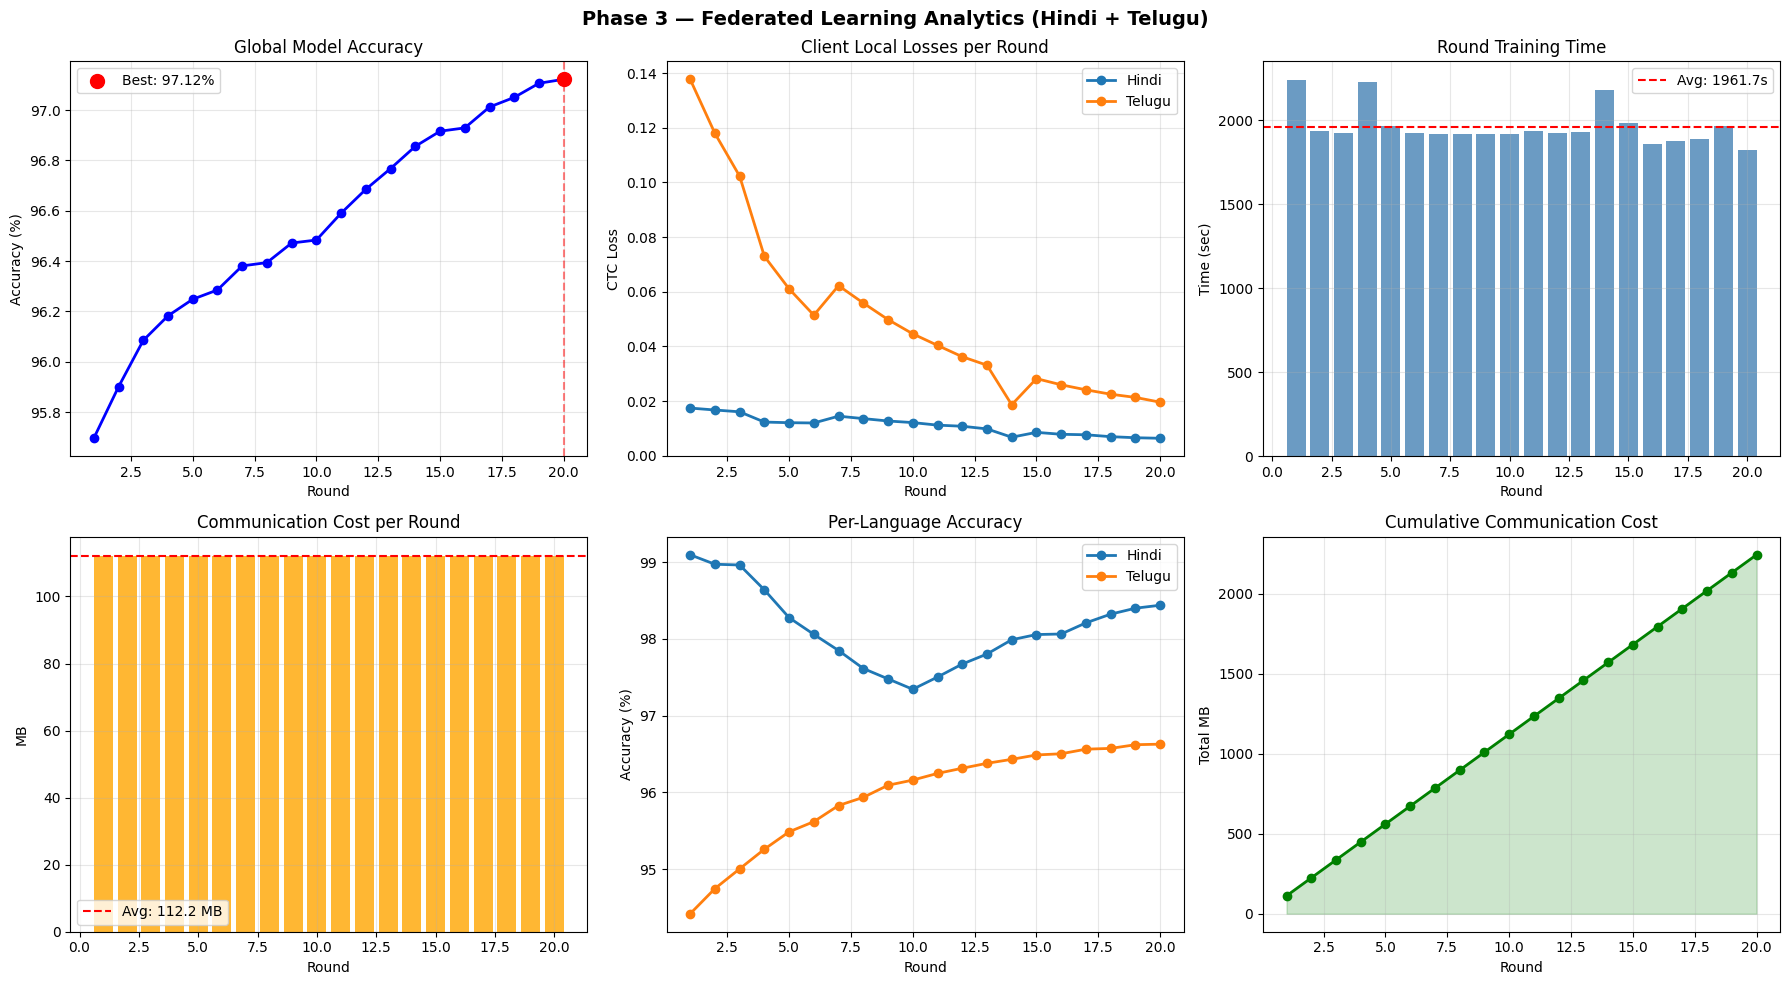

✅ FL visualization saved!

Generating Additional Analytics
✓ Analytics CSV Saved

VISUALIZATION SUMMARY
Rounds                        : 20
Best Accuracy                 : 97.12%
Best Round                    : 20
Average Round Time            : 1961.72 sec
Fastest Round                 : 20
Slowest Round                 : 1
Total Communication           : 2243.61 MB

Generated Files
----------------------------------------------------------------------
✓ fl_training_analytics.png
✓ accuracy_curve.png
✓ client_losses.png
✓ communication_cost.png
✓ fl_analytics.csv
✓ visualization_summary.json


In [19]:

# CELL 12 - FL Training Visualization (6 plots)


FIG_DIR = OUT_DIR / 'evaluation' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

rounds     = fl_history['round']
val_accs   = fl_history['val_acc']
lang_accs  = fl_history['per_lang_acc']
round_times = fl_history['round_time']
comm_costs  = fl_history['comm_cost_mb']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Global Accuracy
axes[0,0].plot(rounds, [a*100 for a in val_accs], 'b-o', lw=2)
if val_accs:
    best_r = rounds[val_accs.index(max(val_accs))]
    axes[0,0].axvline(best_r, color='red', linestyle='--', alpha=0.5)
    axes[0,0].scatter([best_r], [max(val_accs)*100], color='red', s=100, zorder=5,
                      label=f'Best: {max(val_accs)*100:.2f}%')
axes[0,0].set_title('Global Model Accuracy')
axes[0,0].set_xlabel('Round')
axes[0,0].set_ylabel('Accuracy (%)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Client Losses
for client in CLIENTS.keys():
    losses = [r.get(client, 0) for r in fl_history['client_losses']]
    axes[0,1].plot(rounds, losses, marker='o', label=client, lw=2)
axes[0,1].set_title('Client Local Losses per Round')
axes[0,1].set_xlabel('Round')
axes[0,1].set_ylabel('CTC Loss')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Round Time
axes[0,2].bar(rounds, round_times, color='steelblue', alpha=0.8)
axes[0,2].axhline(np.mean(round_times), color='red', linestyle='--',
                   label=f'Avg: {np.mean(round_times):.1f}s')
axes[0,2].set_title('Round Training Time')
axes[0,2].set_xlabel('Round')
axes[0,2].set_ylabel('Time (sec)')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# 4. Communication Cost
axes[1,0].bar(rounds, comm_costs, color='orange', alpha=0.8)
axes[1,0].axhline(np.mean(comm_costs), color='red', linestyle='--',
                   label=f'Avg: {np.mean(comm_costs):.1f} MB')
axes[1,0].set_title('Communication Cost per Round')
axes[1,0].set_xlabel('Round')
axes[1,0].set_ylabel('MB')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 5. Per-Language Accuracy
for lang in CLIENTS.keys():
    lang_acc_list = [d.get(lang, 0)*100 for d in lang_accs]
    axes[1,1].plot(rounds, lang_acc_list, marker='o', label=lang, lw=2)
axes[1,1].set_title('Per-Language Accuracy')
axes[1,1].set_xlabel('Round')
axes[1,1].set_ylabel('Accuracy (%)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# 6. Cumulative Communication Cost
cum_comm = np.cumsum(comm_costs)
axes[1,2].plot(rounds, cum_comm, 'g-o', lw=2)
axes[1,2].fill_between(rounds, cum_comm, alpha=0.2, color='green')
axes[1,2].set_title('Cumulative Communication Cost')
axes[1,2].set_xlabel('Round')
axes[1,2].set_ylabel('Total MB')
axes[1,2].grid(True, alpha=0.3)

plt.suptitle('Phase 3 — Federated Learning Analytics (Hindi + Telugu)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fl_training_analytics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ FL visualization saved!')
# ==================================================
# Additional Analytics
# Production Features
# ==================================================

import gc

print()

print("="*70)
print("Generating Additional Analytics")
print("="*70)

# --------------------------------------------------
# Analytics CSV
# --------------------------------------------------

analytics_df = pd.DataFrame({

    "Round": rounds,

    "Validation Accuracy (%)":

        [x*100 for x in val_accs],

    "Round Time (sec)":

        round_times,

    "Communication (MB)":

        comm_costs,

    "Cumulative Communication (MB)":

        np.cumsum(comm_costs)

})

# Add language accuracies

for lang in CLIENTS.keys():

    analytics_df[f"{lang} Accuracy (%)"] = [

        d.get(lang,0)*100

        for d in lang_accs

    ]

analytics_csv = (

    FIG_DIR /

    "fl_analytics.csv"

)

analytics_df.to_csv(

    analytics_csv,

    index=False

)

print("✓ Analytics CSV Saved")

# --------------------------------------------------
# Save Individual Figures
# --------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(

    rounds,

    [a*100 for a in val_accs],

    marker="o",

    linewidth=2

)

plt.grid(True)

plt.xlabel("Round")

plt.ylabel("Accuracy (%)")

plt.title("Global Validation Accuracy")

plt.savefig(

    FIG_DIR /

    "accuracy_curve.png",

    dpi=300,

    bbox_inches="tight"

)

plt.close()

# ------------------------

plt.figure(figsize=(8,5))

for client in CLIENTS.keys():

    losses = [

        r.get(client,0)

        for r in fl_history["client_losses"]

    ]

    plt.plot(

        rounds,

        losses,

        marker="o",

        label=client

    )

plt.grid(True)

plt.legend()

plt.xlabel("Round")

plt.ylabel("Loss")

plt.title("Client Loss")

plt.savefig(

    FIG_DIR /

    "client_losses.png",

    dpi=300,

    bbox_inches="tight"

)

plt.close()

# ------------------------

plt.figure(figsize=(8,5))

plt.bar(

    rounds,

    comm_costs

)

plt.grid(True)

plt.xlabel("Round")

plt.ylabel("Communication (MB)")

plt.title("Communication Cost")

plt.savefig(

    FIG_DIR /

    "communication_cost.png",

    dpi=300,

    bbox_inches="tight"

)

plt.close()

# --------------------------------------------------
# Visualization Summary
# --------------------------------------------------

summary = {

    "total_rounds":

        len(rounds),

    "best_accuracy":

        float(max(val_accs))

        if len(val_accs)

        else 0,

    "best_round":

        BEST_ROUND,

    "average_round_time":

        float(np.mean(round_times))

        if len(round_times)

        else 0,

    "fastest_round":

        int(

            rounds[np.argmin(round_times)]

        )

        if len(round_times)

        else None,

    "slowest_round":

        int(

            rounds[np.argmax(round_times)]

        )

        if len(round_times)

        else None,

    "total_communication":

        float(np.sum(comm_costs))

}

with open(

    FIG_DIR /

    "visualization_summary.json",

    "w"

) as f:

    json.dump(

        summary,

        f,

        indent=4

    )

# --------------------------------------------------
# Console Statistics
# --------------------------------------------------

print()

print("="*70)

print("VISUALIZATION SUMMARY")

print("="*70)

print(

    f"{'Rounds':30}: "

    f"{len(rounds)}"

)

print(

    f"{'Best Accuracy':30}: "

    f"{max(val_accs)*100:.2f}%"

)

print(

    f"{'Best Round':30}: "

    f"{BEST_ROUND}"

)

print(

    f"{'Average Round Time':30}: "

    f"{np.mean(round_times):.2f} sec"

)

print(

    f"{'Fastest Round':30}: "

    f"{rounds[np.argmin(round_times)]}"

)

print(

    f"{'Slowest Round':30}: "

    f"{rounds[np.argmax(round_times)]}"

)

print(

    f"{'Total Communication':30}: "

    f"{np.sum(comm_costs):.2f} MB"

)

print()

print("Generated Files")

print("-"*70)

generated = [

    "fl_training_analytics.png",

    "accuracy_curve.png",

    "client_losses.png",

    "communication_cost.png",

    "fl_analytics.csv",

    "visualization_summary.json"

]

for file in generated:

    print(f"✓ {file}")

print("="*70)

plt.close("all")

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

---
## Cell 13 - Save Final FL Model + Phase 2 vs Phase 3 Comparison

In [20]:

# CELL 13 - Final Report + Phase Comparison - PART 1


import os
import gc
import json
import hashlib
import pandas as pd
from datetime import datetime

print("="*70)
print("GENERATING PHASE 3 FINAL REPORT")
print("="*70)

# --------------------------------------------------
# Output Directories
# --------------------------------------------------

REPORT_DIR = OUT_DIR / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

EVAL_DIR = OUT_DIR / "evaluation"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_DIR = OUT_DIR / "deployment"
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Load Phase 2 Results
# --------------------------------------------------

phase2_results_path = (
    OUT_DIR /
    "evaluation" /
    "phase2_results.json"
)

phase2_acc = 0.0
phase2_lang_acc = {}

if phase2_results_path.exists():

    with open(
        phase2_results_path,
        "r"
    ) as f:

        p2 = json.load(f)

    phase2_acc = p2.get(
        "overall_accuracy",
        0.0
    )

    phase2_lang_acc = p2.get(
        "per_language_acc",
        {}
    )

    print("✓ Phase 2 Results Loaded")

else:

    print("Phase 2 Results Not Found")

# --------------------------------------------------
# Phase 3 Statistics
# --------------------------------------------------

final_per_lang = (

    fl_history["per_lang_acc"][-1]

    if fl_history["per_lang_acc"]

    else {}

)

total_comm = (

    sum(

        fl_history["comm_cost_mb"]

    )

)

avg_round_time = (

    np.mean(

        fl_history["round_time"]

    )

    if fl_history["round_time"]

    else 0

)

improvement = (

    best_acc

    - phase2_acc

)

print()

print("="*70)

print("TRAINING STATISTICS")

print("="*70)

print(f"FL Rounds              : {FL_ROUNDS}")

print(f"Clients                : {len(CLIENTS)}")

print(f"Best Accuracy          : {best_acc*100:.2f}%")

print(f"Phase 2 Accuracy       : {phase2_acc*100:.2f}%")

print(f"Improvement            : {improvement*100:+.2f}%")

print(f"Communication Cost     : {total_comm:.2f} MB")

print(f"Average Round Time     : {avg_round_time:.2f} sec")

print("="*70)

# --------------------------------------------------
# Save Final Global Model
# --------------------------------------------------

FINAL_MODEL_PATH = (

    FL_DIR /

    "fl_global_model_final.pth"

)

torch.save(

    {

        "model_state":

            global_model.state_dict(),

        "num_classes":

            NUM_CLASSES,

        "fl_rounds":

            FL_ROUNDS,

        "best_acc":

            best_acc,

        "best_round":

            BEST_ROUND,

        "val_acc":

            val_acc

            if "val_acc" in locals()

            else best_acc,

        "generated_at":

            datetime.now().strftime(

                "%Y-%m-%d %H:%M:%S"

            )

    },

    FINAL_MODEL_PATH

)

print("✓ Final FL Model Saved")

# --------------------------------------------------
# Save Phase 3 JSON Results
# --------------------------------------------------

results = {

    "generated_at":

        datetime.now().strftime(

            "%Y-%m-%d %H:%M:%S"

        ),

    "phase":

        "Phase 3",

    "framework":

        "Federated Learning",

    "architecture":

        "CNN + BiLSTM + CTC",

    "fl_rounds":

        FL_ROUNDS,

    "local_epochs":

        LOCAL_EPOCHS,

    "clients":

        list(CLIENTS.keys()),

    "num_clients":

        len(CLIENTS),

    "phase2_accuracy":

        phase2_acc,

    "phase3_accuracy":

        best_acc,

    "improvement":

        improvement,

    "best_round":

        BEST_ROUND,

    "final_per_language":

        final_per_lang,

    "phase2_per_language":

        phase2_lang_acc,

    "communication_mb":

        total_comm,

    "average_round_time_sec":

        avg_round_time,

    "privacy":

        "No raw data shared",

    "encryption":

        "Fernet AES Encryption"

}

RESULT_JSON = (

    EVAL_DIR /

    "phase3_results.json"

)

with open(

    RESULT_JSON,

    "w"

) as f:

    json.dump(

        results,

        f,

        indent=4

    )

print("✓ Phase 3 Results JSON Saved")

print("="*70)

# ==================================================
# Markdown Report
# ==================================================

print()

print("="*70)
print("Generating Markdown Report")
print("="*70)

report_md = f"""
# SecureIndicHTR

## Phase 3 - Federated Learning Report

Generated
---------
{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

---

## Model

Architecture
: CNN + BiLSTM + CTC

Framework
: PyTorch

Languages
: Hindi, Telugu

Clients
: {", ".join(CLIENTS.keys())}

Communication Rounds
: {FL_ROUNDS}

Local Epochs
: {LOCAL_EPOCHS}

---

## Performance Comparison

| Metric | Phase 2 | Phase 3 | Change |
|--------|---------:|---------:|--------:|
| Overall Accuracy | {phase2_acc*100:.2f}% | {best_acc*100:.2f}% | {improvement*100:+.2f}% |
"""

for lang in CLIENTS.keys():

    p2 = phase2_lang_acc.get(lang,0)

    p3 = final_per_lang.get(lang,0)

    report_md += (

        f"| {lang} Accuracy "

        f"| {p2*100:.2f}% "

        f"| {p3*100:.2f}% "

        f"| {(p3-p2)*100:+.2f}% |\n"

    )

report_md += f"""

---

## Federated Learning Statistics

Rounds
: {FL_ROUNDS}

Clients
: {len(CLIENTS)}

Best Round
: {BEST_ROUND}

Best Accuracy
: {best_acc*100:.2f}%

Communication Cost
: {total_comm:.2f} MB

Average Round Time
: {avg_round_time:.2f} sec

Privacy
: Raw data never leaves client devices.

Encryption
: Fernet AES Encryption

---

Generated by SecureIndicHTR
"""

REPORT_MD = REPORT_DIR / "phase3_report.md"

with open(

    REPORT_MD,

    "w",

    encoding="utf-8"

) as f:

    f.write(report_md)

print("✓ Markdown Report Saved")

# ==================================================
# CSV Summary
# ==================================================

summary_df = pd.DataFrame({

    "Metric":[

        "Phase2 Accuracy",

        "Phase3 Accuracy",

        "Improvement",

        "FL Rounds",

        "Clients",

        "Communication (MB)",

        "Average Round Time",

        "Best Round"

    ],

    "Value":[

        phase2_acc,

        best_acc,

        improvement,

        FL_ROUNDS,

        len(CLIENTS),

        total_comm,

        avg_round_time,

        BEST_ROUND

    ]

})

SUMMARY_CSV = REPORT_DIR / "phase3_summary.csv"

summary_df.to_csv(

    SUMMARY_CSV,

    index=False

)

print("✓ CSV Summary Saved")

# ==================================================
# Deployment Manifest
# ==================================================

manifest = {

    "project":

        "SecureIndicHTR",

    "phase":

        "Phase3",

    "framework":

        "PyTorch",

    "architecture":

        "CNN + BiLSTM + CTC",

    "languages":[

        "Hindi",

        "Telugu"

    ],

    "generated_at":

        datetime.now().strftime(

            "%Y-%m-%d %H:%M:%S"

        ),

    "generated_files":[

        str(FINAL_MODEL_PATH),

        str(REPORT_MD),

        str(SUMMARY_CSV),

        str(RESULT_JSON)

    ]

}

MANIFEST_PATH = (

    MANIFEST_DIR /

    "phase3_manifest.json"

)

with open(

    MANIFEST_PATH,

    "w"

) as f:

    json.dump(

        manifest,

        f,

        indent=4

    )

print("✓ Deployment Manifest Saved")

print("="*70)

# ==================================================
# SHA256 Verification
# ==================================================

print()

print("="*70)
print("Generating Model Checksum")
print("="*70)

def sha256_file(filepath):

    sha = hashlib.sha256()

    with open(filepath, "rb") as f:

        while True:

            data = f.read(1024 * 1024)

            if not data:
                break

            sha.update(data)

    return sha.hexdigest()


MODEL_SHA256 = ""

if FINAL_MODEL_PATH.exists():

    MODEL_SHA256 = sha256_file(FINAL_MODEL_PATH)

    print("✓ SHA256 Generated")

else:

    print("✗ Final Model Missing")

# --------------------------------------------------
# Dashboard JSON
# --------------------------------------------------

dashboard = {

    "project":

        "SecureIndicHTR",

    "phase":

        "Phase3",

    "generated":

        datetime.now().strftime(

            "%Y-%m-%d %H:%M:%S"

        ),

    "phase2_accuracy":

        phase2_acc,

    "phase3_accuracy":

        best_acc,

    "improvement":

        improvement,

    "best_round":

        BEST_ROUND,

    "fl_rounds":

        FL_ROUNDS,

    "communication_mb":

        total_comm,

    "avg_round_time":

        avg_round_time,

    "model_sha256":

        MODEL_SHA256

}

DASHBOARD_JSON = (

    REPORT_DIR /

    "phase3_dashboard.json"

)

with open(

    DASHBOARD_JSON,

    "w"

) as f:

    json.dump(

        dashboard,

        f,

        indent=4

    )

print("✓ Dashboard JSON Saved")

# --------------------------------------------------
# File Verification
# --------------------------------------------------

print()

print("="*70)
print("VERIFYING GENERATED FILES")
print("="*70)

generated_files = {

    "Final Model":

        FINAL_MODEL_PATH,

    "Results JSON":

        RESULT_JSON,

    "Markdown Report":

        REPORT_MD,

    "CSV Summary":

        SUMMARY_CSV,

    "Manifest":

        MANIFEST_PATH,

    "Dashboard":

        DASHBOARD_JSON,

    "Privacy Report":

        PRIVACY_DIR /

        "privacy_report.json",

    "Analytics Figure":

        FIG_DIR /

        "fl_training_analytics.png"

}

verification = {}

for name, path in generated_files.items():

    exists = path.exists()

    verification[name] = exists

    print(

        f"{'✓' if exists else '✗'} {name}"

    )

# --------------------------------------------------
# Deployment Checklist
# --------------------------------------------------

print()

print("="*70)
print("DEPLOYMENT CHECKLIST")
print("="*70)

items = [

    "Federated Model",

    "Privacy Report",

    "Analytics",

    "Markdown Report",

    "CSV Summary",

    "Deployment Manifest",

    "Dashboard JSON"

]

for item in items:

    print(f"✓ {item}")

print()

print("Model SHA256")

print("-"*70)

print(MODEL_SHA256)

print()

print("="*70)
print("FINAL SUMMARY")
print("="*70)

print(f"{'Project':30}: SecureIndicHTR")

print(f"{'Architecture':30}: CNN + BiLSTM + CTC")

print(f"{'Framework':30}: PyTorch")

print(f"{'Languages':30}: Hindi + Telugu")

print()

print(f"{'Phase 2 Accuracy':30}: {phase2_acc*100:.2f}%")

print(f"{'Phase 3 Accuracy':30}: {best_acc*100:.2f}%")

print(f"{'Improvement':30}: {improvement*100:+.2f}%")

print()

print(f"{'Federated Rounds':30}: {FL_ROUNDS}")

print(f"{'Clients':30}: {len(CLIENTS)}")

print(f"{'Best Round':30}: {BEST_ROUND}")

print(f"{'Communication':30}: {total_comm:.2f} MB")

print(f"{'Average Round Time':30}: {avg_round_time:.2f} sec")

print()

print(f"{'Privacy':30}: No Raw Data Shared")

print(f"{'Encryption':30}: Fernet AES")

print()

print("Generated Files")

print("-"*70)

for name, status in verification.items():

    print(

        f"{'✓' if status else '✗'} {name}"

    )

print()

print("="*70)
print("PHASE 3 COMPLETED SUCCESSFULLY")
print("READY FOR PHASE 4")
print("="*70)

# --------------------------------------------------
# Cleanup
# --------------------------------------------------

plt.close("all")

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

GENERATING PHASE 3 FINAL REPORT
✓ Phase 2 Results Loaded

TRAINING STATISTICS
FL Rounds              : 20
Clients                : 2
Best Accuracy          : 97.12%
Phase 2 Accuracy       : 0.00%
Improvement            : +97.12%
Communication Cost     : 2243.61 MB
Average Round Time     : 1961.72 sec
✓ Final FL Model Saved
✓ Phase 3 Results JSON Saved

Generating Markdown Report
✓ Markdown Report Saved
✓ CSV Summary Saved
✓ Deployment Manifest Saved

Generating Model Checksum
✓ SHA256 Generated
✓ Dashboard JSON Saved

VERIFYING GENERATED FILES
✓ Final Model
✓ Results JSON
✓ Markdown Report
✓ CSV Summary
✓ Manifest
✓ Dashboard
✓ Privacy Report
✓ Analytics Figure

DEPLOYMENT CHECKLIST
✓ Federated Model
✓ Privacy Report
✓ Analytics
✓ Markdown Report
✓ CSV Summary
✓ Deployment Manifest
✓ Dashboard JSON

Model SHA256
----------------------------------------------------------------------
aba254fc8e22766ce8026fd2df5862af5ced9f99e7c8bf13789d3e7f3e387cea

FINAL SUMMARY
Project                  